In [13]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [14]:
# Load IMDb dataset from Keras
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

In [15]:
max_words = 10000
maxlen = 10000
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [16]:
model = Sequential()
# Add an Embedding layer without loading pretrained embeddings and without freezing the layer
model.add(Embedding(input_dim=max_words, output_dim=8, input_length=maxlen))
model.add(Flatten())
model.add(Dense(units=1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 10000, 8)          80000     
                                                                 
 flatten_2 (Flatten)         (None, 80000)             0         
                                                                 
 dense_2 (Dense)             (None, 1)                 80001     
                                                                 
Total params: 160,001
Trainable params: 160,001
Non-trainable params: 0
_________________________________________________________________


In [17]:
# Train the model
history=model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
625/625 [==============================] - 9s 15ms/step - loss: 0.4926 - accuracy: 0.7503 - val_loss: 0.3121 - val_accuracy: 0.8794
Epoch 2/10
625/625 [==============================] - 10s 17ms/step - loss: 0.2385 - accuracy: 0.9104 - val_loss: 0.2715 - val_accuracy: 0.8894
Epoch 3/10
625/625 [==============================] - 10s 15ms/step - loss: 0.1735 - accuracy: 0.9381 - val_loss: 0.2719 - val_accuracy: 0.8884
Epoch 4/10
625/625 [==============================] - 9s 14ms/step - loss: 0.1328 - accuracy: 0.9564 - val_loss: 0.2828 - val_accuracy: 0.8902
Epoch 5/10
625/625 [==============================] - 9s 14ms/step - loss: 0.1017 - accuracy: 0.9693 - val_loss: 0.3062 - val_accuracy: 0.8870
Epoch 6/10
625/625 [==============================] - 9s 14ms/step - loss: 0.0775 - accuracy: 0.9797 - val_loss: 0.3194 - val_accuracy: 0.8856
Epoch 7/10
625/625 [==============================] - 9s 15ms/step - loss: 0.0575 - accuracy: 0.9870 - val_loss: 0.3428 - val_accuracy: 0.88

In [18]:
model.save('pretrained_model.h5')

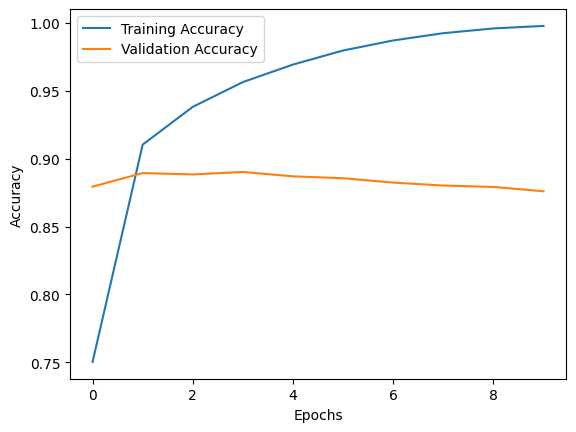

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

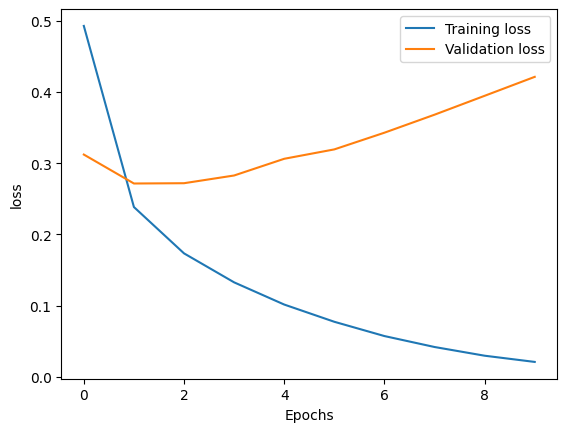

In [20]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()